# Heart Disease Prediction Project

Welcome to the Heart Disease Prediction project! ❤️‍🔥

In this notebook, we'll walk through a complete beginner-friendly machine learning workflow to predict the risk of heart disease using the Framingham Heart Study dataset.

## 🔍 Objective

Our goal is to build a machine learning model that can predict whether a person is at risk of developing heart disease based on several health and demographic features.

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

## 📥 Step 1: Load the Dataset

In [47]:
df = pd.read_csv('framingham[1].csv')
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


## 🔍 Step 2: Explore the Dataset

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [49]:
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4240.000000,4135.000000,4240.000000,4211.000000,4187.000000,4240.000000,4240.000000,4240.000000,4190.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4240.000000
mean,0.429245,49.580189,1.979444,0.494104,9.005937,0.029615,0.005896,0.310613,0.025708,236.699523,132.354599,82.897759,25.800801,75.878981,81.963655,0.151887
std,0.495027,8.572942,1.019791,0.500024,11.922462,0.169544,0.076569,0.462799,0.158280,44.591284,22.033300,11.910394,4.079840,12.025348,23.954335,0.358953
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,90.000000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [50]:
df['TenYearCHD'].value_counts()

,count
TenYearCHD,
0,3596
1,644


## 🧹 Step 3: Clean the Data

We'll handle any missing values and remove irrelevant columns if needed.

In [51]:
print("Missing Values before Cleaning:\n", df.isnull().sum())

df = df.dropna()

print("\n Missing Values before cleaning :\n",df.isnull().sum())
print("\n Cleaning dataset shape:", df.shape)

Missing Values before Cleaning:
 male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

 Missing Values before cleaning :
 male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

 Cleaning dataset shape: (3658, 16)


## 📊 Step 4: Visualize the Data

/tmp/ipykernel_5061/3989313565.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='TenYearCHD', data=df, palette='coolwarm')


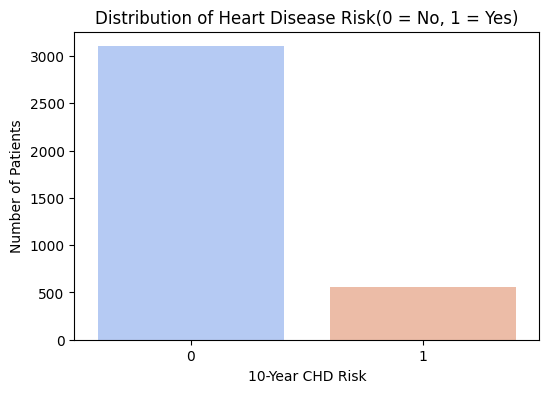

/tmp/ipykernel_5061/3989313565.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='TenYearCHD', y='age', data=df, palette='Set2')


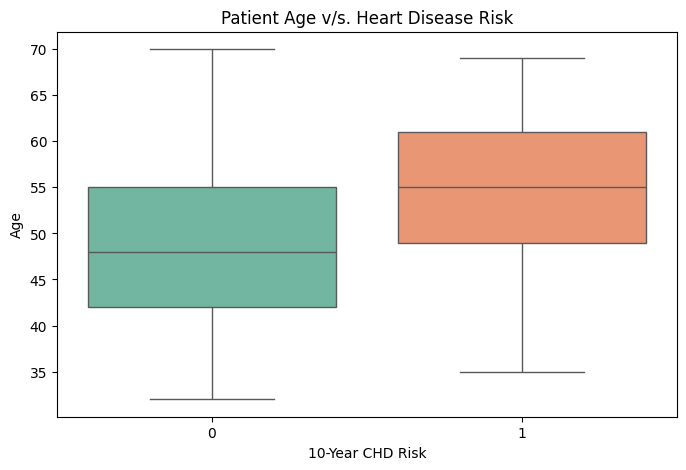

In [52]:
plt.figure(figsize=(6, 4))
sns.countplot(x='TenYearCHD', data=df, palette='coolwarm')
plt.title('Distribution of Heart Disease Risk(0 = No, 1 = Yes)')
plt.xlabel('10-Year CHD Risk')
plt.ylabel('Number of Patients')
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x='TenYearCHD', y='age', data=df, palette='Set2')
plt.title('Patient Age v/s. Heart Disease Risk')
plt.xlabel('10-Year CHD Risk')
plt.ylabel('Age')
plt.show()

## ⚙️ Step 5: Preprocess the Data

In [53]:
# Split features and target

x = df.drop('TenYearCHD', axis=1)
y =df['TenYearCHD']

# Train-test split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

#[ Scale the features

scaler = StandardScaler()
x_trian = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

print("Data Preprocessing Complete!")
print("Training data shape: ",x_train.shape)


Data Preprocessing Complete!
Training data shape:  (2926, 15)


## 🤖 Step 6: Train a Machine Learning Model

In [57]:
# Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

print("Model Successfully Trained !")

Model Successfully Trained !


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 🧪 Step 7: Evaluate the Model

In [56]:
predictions = model.predict(x_test)

print(f"Accuray Score : {accuracy_score(y_test, predictions) * 100:.2f}%\n")

print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, predictions))
print("\n--- Classification Report ---")
print(classification_report(y_test, predictions))

Accuray Score : 83.06%

--- Confusion Matrix ---
[[608   2]
 [122   0]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.83      1.00      0.91       610
           1       0.00      0.00      0.00       122

    accuracy                           0.83       732
   macro avg       0.42      0.50      0.45       732
weighted avg       0.69      0.83      0.76       732



/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


# Conclusion

---



Completing this workflow provided a comprehensive, hands-on experience in building a real-world machine learning pipeline. Using the Framingham dataset, I successfully developed and evaluated a baseline Logistic Regression model to predict long-term heart disease risk. This project reinforced core data science practices, taking the clinical data through its entire lifecycle—from initial loading and dropping incomplete records to feature scaling and final evaluation.
#

# 🚀 Next Steps for Optimization

 * Advanced Modeling: Experimenting with more complex, robust algorithms like Random Forest or XGBoost to better capture non-linear relationships in the patient health data.

* Refined Data Imputation: Implementing more advanced techniques for handling missing values (such as median or KNN imputation) rather than simply dropping incomplete rows, ensuring no valuable medical data is lost.

* Feature Engineering & Tuning: Conducting strict feature selection to isolate the most critical cardiovascular indicators and applying hyperparameter tuning to maximize the model's predictive power.